# Sales Prediction — Initial Model Training

**CodSoft Data Science Internship — Task 4: Sales Prediction Using Python**
(local folder `Task2_Sales_Prediction`, my own project numbering)

**Phase 3.** Phases [1](01_dataset_audit.ipynb) and [2](02_data_preprocessing.ipynb) are the source of truth
for the dataset, the split and the preprocessing; this notebook uses them unchanged.

**This is a first comparison, not a final result.** No hyperparameter is tuned here, no search is run, and no
model is saved. Phase 4 handles improvement and validation.

---
## 1. Phase Objective

Establish a naive reference point, fit several regression models on the fixed Phase 2 training set, evaluate
them all on the same untouched 40-row test set, and identify an initial candidate to carry into Phase 4.

### What this phase deliberately does **not** do

| Not done here | Why |
|---|---|
| Hyperparameter tuning, grid or random search | Phase 4, using cross-validation on the **training** set |
| Choosing settings by looking at test scores | That would turn the hold-out into a validation set and inflate every number reported afterwards |
| Saving a model artefact | Nothing here is final enough to persist |
| Removing the two `Newspaper` outliers | Phase 2 decided to retain them; section 16 examines them instead |

Each model is fitted once, with the configuration fixed in advance, and its test score is read once.

### A caution that applies to every number below

The test set is **40 rows**. Differences of a few hundredths of an RMSE unit between two models are well
inside the noise of a sample that small. Where two models are close, this notebook says so rather than
declaring a winner.

---
## 2. Load and Prepare Data

The preprocessing is imported from [`../src/data_preprocessing.py`](../src/data_preprocessing.py) — the same
module Phase 2 built and validated. Nothing about the split or the transformation is redefined here.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").is_dir() else NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_DIR / "src"
VIZ_DIR = PROJECT_DIR / "visualizations"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import data_preprocessing as dp

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = dp.RANDOM_STATE

print("project directory :", PROJECT_DIR.name)
print("preprocessing from:", Path(dp.__file__).relative_to(PROJECT_DIR))
print("random_state      :", RANDOM_STATE)

project directory : Task2_Sales_Prediction
preprocessing from: src\data_preprocessing.py
random_state      : 42


In [2]:
df = dp.load_raw_data()
X, y = dp.split_features_target(df)

print(f"dataset shape : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"predictors    : {list(X.columns)}")
print(f"target        : {y.name}")

dataset shape : 200 rows x 4 columns
predictors    : ['TV', 'Radio', 'Newspaper']
target        : Sales


---
## 3. Recreate Fixed Train/Test Split

The split is rebuilt from the module rather than carried over from another notebook's state, and is then
checked against the Phase 2 contract. A mismatch would mean Phase 2's hold-out is not the one being used
here, so it raises rather than proceeding quietly.

In [3]:
split = dp.make_train_test_split(X, y, test_size=dp.TEST_SIZE, random_state=dp.RANDOM_STATE)
X_train, X_test = split.X_train, split.X_test
y_train, y_test = split.y_train, split.y_test

print(f"test_size    : {split.test_size}")
print(f"random_state : {split.random_state}")
print(f"X_train      : {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test       : {X_test.shape}    y_test : {y_test.shape}")

test_size    : 0.2
random_state : 42
X_train      : (160, 3)   y_train: (160,)
X_test       : (40, 3)    y_test : (40,)


In [4]:
# Independent reconstruction through the full Phase 2 entry point, as a cross-check.
phase2 = dp.prepare_modeling_data()

split_checks = pd.DataFrame([
    {"Check": "200 rows in total", "Passed": len(df) == 200},
    {"Check": "160 training rows", "Passed": len(X_train) == 160},
    {"Check": "40 test rows", "Passed": len(X_test) == 40},
    {"Check": "split covers every row", "Passed": len(X_train) + len(X_test) == 200},
    {"Check": "random_state is 42", "Passed": split.random_state == 42},
    {"Check": "test_size is 0.2", "Passed": split.test_size == 0.2},
    {"Check": "matches Phase 2 X_train", "Passed": X_train.equals(phase2.X_train)},
    {"Check": "matches Phase 2 X_test", "Passed": X_test.equals(phase2.X_test)},
    {"Check": "matches Phase 2 y_train", "Passed": y_train.equals(phase2.y_train)},
    {"Check": "matches Phase 2 y_test", "Passed": y_test.equals(phase2.y_test)},
    {"Check": "no row shared between train and test",
     "Passed": X_train.index.intersection(X_test.index).empty},
    {"Check": "X / y aligned on both sides",
     "Passed": X_train.index.equals(y_train.index) and X_test.index.equals(y_test.index)},
])
display(split_checks)

assert split_checks["Passed"].all(), (
    "The split does not match Phase 2. STOP and investigate before training anything."
)
print("\nSplit reproduced exactly as Phase 2 defined it.")
print("first 10 test indices:", list(X_test.index[:10]))

,Check,Passed
0,200 rows in total,True
1,160 training rows,True
2,40 test rows,True
3,split covers every row,True
4,random_state is 42,True
5,test_size is 0.2,True
6,matches Phase 2 X_train,True
7,matches Phase 2 X_test,True
8,matches Phase 2 y_train,True
9,matches Phase 2 y_test,True



Split reproduced exactly as Phase 2 defined it.
first 10 test indices: [95, 15, 30, 158, 128, 115, 69, 170, 174, 45]


**Result.** 160 training rows and 40 test rows, identical to Phase 2 in content and in row order.

From here the 40 test rows are used for exactly one thing: scoring a model that has already been fitted. No
model's configuration is chosen by looking at them.

---
### Evaluation function

One function, used identically for the baseline and for every model, so no metric can be computed a
different way for a different row of the comparison table.

This is a **regression** problem — a continuous target — so there is no such thing as accuracy here. The
metrics are:

- **MAE** — mean absolute error, in sales units. The typical miss.
- **MSE** — mean squared error, in squared sales units. Penalises large misses disproportionately.
- **RMSE** — root mean squared error, back in sales units. Comparable to MAE, but more sensitive to a few
  large errors.
- **R²** — the share of variance in `Sales` explained, relative to always predicting the mean. 0 means no
  better than that; it can go negative when a model does worse.

In [5]:
def evaluate(y_true, y_pred) -> dict:
    """Return MAE, MSE, RMSE and R² for a set of regression predictions."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if y_true.shape != y_pred.shape:
        raise ValueError(f"shape mismatch: y_true {y_true.shape} vs y_pred {y_pred.shape}")
    if not np.isfinite(y_pred).all():
        raise ValueError("predictions contain NaN or infinite values")

    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "R2": r2_score(y_true, y_pred),
    }


results = {}


def record(name, y_train_pred, y_test_pred):
    """Evaluate a fitted approach on both splits and store the result."""
    if len(y_test_pred) != len(y_test):
        raise ValueError(f"expected {len(y_test)} test predictions, got {len(y_test_pred)}")
    train_metrics = evaluate(y_train, y_train_pred)
    test_metrics = evaluate(y_test, y_test_pred)
    results[name] = {"train": train_metrics, "test": test_metrics,
                     "y_test_pred": np.asarray(y_test_pred, dtype=float)}
    print(f"{name}")
    print(f"  train  MAE {train_metrics['MAE']:7.4f} | MSE {train_metrics['MSE']:8.4f} | "
          f"RMSE {train_metrics['RMSE']:7.4f} | R2 {train_metrics['R2']:7.4f}")
    print(f"  test   MAE {test_metrics['MAE']:7.4f} | MSE {test_metrics['MSE']:8.4f} | "
          f"RMSE {test_metrics['RMSE']:7.4f} | R2 {test_metrics['R2']:7.4f}")
    return test_metrics


def make_pipeline(estimator) -> Pipeline:
    """Compose the Phase 2 preprocessor with an estimator.

    Keeping them in one object means the scaler is fitted on the training rows inside ``fit`` and merely
    applied inside ``predict`` — the transformation can never be accidentally refitted on test data, and the
    whole thing can be handed to cross-validation in Phase 4 without changing anything.
    """
    return Pipeline([("preprocessor", dp.build_preprocessor()), ("model", estimator)])

---
## 4. Baseline Model

A reference point, **not a machine learning model**. It ignores the advertising budgets entirely and predicts
the same number for every observation: the mean `Sales` of the training set.

The mean is taken from `y_train` only. Using the full dataset's mean would leak the test rows into the
reference and make every model's improvement look smaller than it is.

In [6]:
baseline_value = float(y_train.mean())

print(f"mean of y_train (160 rows) : {baseline_value:.6f}")
print(f"mean of y_test  (40 rows)  : {y_test.mean():.6f}   <- not used, shown only for contrast")
print(f"mean of all 200 rows       : {y.mean():.6f}   <- deliberately NOT used")

assert not np.isclose(baseline_value, y.mean()), "Baseline appears to use the full dataset mean."

baseline_train_pred = np.full(len(y_train), baseline_value)
baseline_test_pred = np.full(len(y_test), baseline_value)

record("Baseline (train mean)", baseline_train_pred, baseline_test_pred)

mean of y_train (160 rows) : 15.330625
mean of y_test  (40 rows)  : 14.330000   <- not used, shown only for contrast
mean of all 200 rows       : 15.130500   <- deliberately NOT used
Baseline (train mean)
  train  MAE  4.2908 | MSE  26.7994 | RMSE  5.1768 | R2  0.0000
  test   MAE  4.9315 | MSE  31.9024 | RMSE  5.6482 | R2 -0.0324


{'MAE': 4.93153125,
 'MSE': 31.902350390624996,
 'RMSE': 5.648216567255986,
 'R2': -0.032401771801812806}

**Result.** Predicting a constant 15.3306 gives a test RMSE of **5.6482** and MAE of **4.9315**.

Two details worth reading correctly:

- Train R² is exactly **0.0000**. That is definitional, not a coincidence: R² measures improvement over the
  mean of the data being scored, and on the training set this predictor *is* that mean.
- Test R² is **−0.0324**, slightly negative. Also expected: the test rows have their own mean, and the
  training mean is not quite it. A negative R² simply means "worse than predicting this set's own average",
  which a constant fitted elsewhere naturally is.

Every model below has to beat 5.6482 test RMSE to have earned its complexity.

---
## 5. Linear Regression

Ordinary least squares, composed with the Phase 2 preprocessor. Fitted on `X_train`/`y_train`, predictions
taken on `X_test`. No hyperparameters to set, and none tuned.

In [7]:
lin_pipe = make_pipeline(LinearRegression())
lin_pipe.fit(X_train, y_train)

record("Linear Regression", lin_pipe.predict(X_train), lin_pipe.predict(X_test))

Linear Regression
  train  MAE  1.2344 | MSE   2.6761 | RMSE  1.6359 | R2  0.9001
  test   MAE  1.2748 | MSE   2.9078 | RMSE  1.7052 | R2  0.9059


{'MAE': 1.2748262109549349,
 'MSE': 2.9077569102710923,
 'RMSE': 1.7052146229349232,
 'R2': 0.9059011844150826}

In [8]:
lin_coefs = pd.DataFrame({
    "Coefficient (standardised units)": lin_pipe.named_steps["model"].coef_,
}, index=dp.FEATURE_COLUMNS)
lin_coefs.loc["(intercept)"] = lin_pipe.named_steps["model"].intercept_
lin_coefs

,Coefficient (standardised units)
TV,4.5872
Radio,1.4898
Newspaper,0.0879
(intercept),15.3306


**Result.** Test RMSE **1.7052**, MAE **1.2748**, R² **0.9059** — a large improvement on the baseline.

Because the features are standardised, the coefficients are directly comparable to one another: a one
standard-deviation increase in `TV` is associated with about **+4.59** sales units, `Radio` with **+1.49**,
and `Newspaper` with **+0.09**. That ordering matches the correlations Phase 1 found, and `Newspaper`'s
near-zero weight suggests it contributes little once the other two are accounted for.

These are associations within a fitted model, not causal effects. Nothing in this data can establish that
increasing a budget *causes* sales to rise.

---
## 6. Ridge Regression

`alpha = 1.0`, chosen in advance as a conventional starting value. **No alpha search is run** — that is a
Phase 4 task, and doing it here against the test set would corrupt the hold-out.

In [9]:
ridge_pipe = make_pipeline(Ridge(alpha=1.0, random_state=RANDOM_STATE))
ridge_pipe.fit(X_train, y_train)

record("Ridge (alpha=1.0)", ridge_pipe.predict(X_train), ridge_pipe.predict(X_test))

Ridge (alpha=1.0)


  train  MAE  1.2362 | MSE   2.6770 | RMSE  1.6362 | R2  0.9001
  test   MAE  1.2734 | MSE   2.9153 | RMSE  1.7074 | R2  0.9057


{'MAE': 1.2734471720192524,
 'MSE': 2.9153180135113756,
 'RMSE': 1.7074302367919387,
 'R2': 0.9056564972278859}

**Result.** Test RMSE **1.7074** — a hair worse than plain OLS (1.7052), and the difference is far too small
to mean anything on 40 rows.

This is the expected outcome rather than a disappointment. Ridge helps when coefficients are unstable, which
happens with correlated predictors or with many features relative to rows. Phase 1 found neither: the
strongest predictor pair correlates at 0.354, and there are 3 features for 160 training rows. With nothing
to stabilise, the penalty can only shrink coefficients slightly away from the least-squares solution.

---
## 7. Lasso Regression

`alpha = 0.01`, again fixed in advance and not searched.

In [10]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")

    lasso_pipe = make_pipeline(Lasso(alpha=0.01, random_state=RANDOM_STATE))
    lasso_pipe.fit(X_train, y_train)

    convergence_warnings = [w for w in caught if "onvergence" in str(w.message)]

print(f"warnings raised during fit : {len(caught)}")
print(f"convergence warnings       : {len(convergence_warnings)}")
for w in caught:
    print("  -", w.category.__name__, str(w.message).splitlines()[0])

lasso_model = lasso_pipe.named_steps["model"]
print(f"\niterations run: {lasso_model.n_iter_}  (max_iter = {lasso_model.max_iter}, left at the default)")

warnings raised during fit : 0
convergence warnings       : 0

iterations run: 5  (max_iter = 1000, left at the default)


In [11]:
record("Lasso (alpha=0.01)", lasso_pipe.predict(X_train), lasso_pipe.predict(X_test))

Lasso (alpha=0.01)
  train  MAE  1.2360 | MSE   2.6764 | RMSE  1.6360 | R2  0.9001
  test   MAE  1.2725 | MSE   2.9071 | RMSE  1.7050 | R2  0.9059


{'MAE': 1.2725128416472886,
 'MSE': 2.9071265601111955,
 'RMSE': 1.70502978276369,
 'R2': 0.9059215833704563}

In [12]:
coef_comparison = pd.DataFrame({
    "Linear": lin_pipe.named_steps["model"].coef_,
    "Ridge (alpha=1.0)": ridge_pipe.named_steps["model"].coef_,
    "Lasso (alpha=0.01)": lasso_model.coef_,
}, index=dp.FEATURE_COLUMNS)
coef_comparison.loc["(intercept)"] = [
    lin_pipe.named_steps["model"].intercept_,
    ridge_pipe.named_steps["model"].intercept_,
    lasso_model.intercept_,
]
display(coef_comparison)

print("coefficients driven exactly to zero by Lasso:",
      [c for c, v in zip(dp.FEATURE_COLUMNS, lasso_model.coef_) if v == 0] or "none")

,Linear,Ridge (alpha=1.0),Lasso (alpha=0.01)
TV,4.5872,4.5591,4.5777
Radio,1.4898,1.4807,1.4832
Newspaper,0.0879,0.0914,0.0807
(intercept),15.3306,15.3306,15.3306


coefficients driven exactly to zero by Lasso: none


**Convergence.** No warnings of any kind were raised. The coordinate-descent solver converged in well under
the default `max_iter`, so `max_iter` was **left at its default** — there was no convergence problem to
paper over, and raising it arbitrarily would have hidden nothing and proved nothing.

**Result.** Test RMSE **1.7050**, marginally the best of the three linear models — by 0.0002 RMSE units over
OLS, which is noise, not a finding. All three are the same model for practical purposes.

At `alpha = 0.01` the penalty is light: no coefficient is driven to exactly zero, though `Newspaper` shrinks
further (0.0807 vs 0.0879 for OLS). A larger alpha would likely eliminate `Newspaper` altogether — an
interesting question, and one for Phase 4's cross-validation, not for a test-set experiment here.

---
## 8. Random Forest Regression

`n_estimators=300`, `random_state=42`, `n_jobs=-1`. Configuration fixed in advance; nothing tuned.

The Phase 2 pipeline is used unchanged even though a random forest does not need scaling. Standardisation is
a monotone per-column transformation, and a tree's splits depend only on the *order* of values within a
column — so the fitted forest is identical either way. Keeping one pipeline for every model means the
comparison below differs only in the estimator, which is the point of a comparison.

In [13]:
rf_pipe = make_pipeline(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
rf_pipe.fit(X_train, y_train)

record("Random Forest", rf_pipe.predict(X_train), rf_pipe.predict(X_test))

Random Forest
  train  MAE  0.3247 | MSE   0.2224 | RMSE  0.4716 | R2  0.9917
  test   MAE  0.9025 | MSE   1.3918 | RMSE  1.1798 | R2  0.9550


{'MAE': 0.9025499999999986,
 'MSE': 1.3918453777777713,
 'RMSE': 1.1797649671768404,
 'R2': 0.9549580637007171}

In [14]:
rf_importance = pd.DataFrame({
    "Impurity-based importance": rf_pipe.named_steps["model"].feature_importances_,
}, index=dp.FEATURE_COLUMNS).sort_values("Impurity-based importance", ascending=False)
rf_importance

,Impurity-based importance
TV,0.8453
Radio,0.1363
Newspaper,0.0184


**Result.** Test RMSE **1.1798**, MAE **0.9025**, R² **0.9550** — a clear improvement on the linear models
(1.705), suggesting the relationship is not purely additive and linear. The most likely reason is an
interaction: the effect of radio spend plausibly differs depending on how much is being spent on TV, which a
tree captures and a plain linear model cannot.

Train RMSE is **0.4716** against test RMSE 1.1798. A random forest fitted without depth limits reproduces its
training data closely by construction, so a gap of this kind is expected rather than alarming; section 18
interprets it properly.

The impurity-based importances repeat the familiar ordering, with `TV` dominant. They are a rough diagnostic
— impurity importance is known to favour continuous, high-cardinality features — and are reported here as
context, not as evidence of effect size.

---
## 9. Gradient Boosting Regression

`n_estimators=200`, `learning_rate=0.05`, `max_depth=3`, `random_state=42`. Fixed in advance; nothing tuned.

In [15]:
gb_pipe = make_pipeline(GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
))
gb_pipe.fit(X_train, y_train)

record("Gradient Boosting", gb_pipe.predict(X_train), gb_pipe.predict(X_test))

Gradient Boosting
  train  MAE  0.3376 | MSE   0.1970 | RMSE  0.4438 | R2  0.9926
  test   MAE  0.8679 | MSE   1.3113 | RMSE  1.1451 | R2  0.9576


{'MAE': 0.8679329652881087,
 'MSE': 1.311267203622774,
 'RMSE': 1.145105760889698,
 'R2': 0.9575656787744522}

**Result.** Test RMSE **1.1451**, MAE **0.8679**, R² **0.9576** — the lowest test RMSE of the six approaches.

It sits **0.035 RMSE units** below the random forest. On 40 test rows that difference is not meaningful; the
two should be read as performing comparably, not as first and second place. Section 14 returns to this.

---
## 10. Model Comparison

In [16]:
comparison = pd.DataFrame([
    {
        "Model": name,
        "Train MAE": r["train"]["MAE"],
        "Test MAE": r["test"]["MAE"],
        "Train MSE": r["train"]["MSE"],
        "Test MSE": r["test"]["MSE"],
        "Train RMSE": r["train"]["RMSE"],
        "Test RMSE": r["test"]["RMSE"],
        "Train R2": r["train"]["R2"],
        "Test R2": r["test"]["R2"],
    }
    for name, r in results.items()
]).sort_values("Test RMSE").reset_index(drop=True)

comparison

,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2
0,Gradient Boosting,0.3376,0.8679,0.1970,1.3113,0.4438,1.1451,0.9926,0.9576
1,Random Forest,0.3247,0.9025,0.2224,1.3918,0.4716,1.1798,0.9917,0.9550
2,Lasso (alpha=0.01),1.2360,1.2725,2.6764,2.9071,1.6360,1.7050,0.9001,0.9059
3,Linear Regression,1.2344,1.2748,2.6761,2.9078,1.6359,1.7052,0.9001,0.9059
4,Ridge (alpha=1.0),1.2362,1.2734,2.6770,2.9153,1.6362,1.7074,0.9001,0.9057
5,Baseline (train mean),4.2908,4.9315,26.7994,31.9024,5.1768,5.6482,0.0000,-0.0324


In [17]:
baseline_rmse = results["Baseline (train mean)"]["test"]["RMSE"]
baseline_mae = results["Baseline (train mean)"]["test"]["MAE"]

improvement = comparison.assign(**{
    "RMSE vs baseline": (baseline_rmse - comparison["Test RMSE"]) / baseline_rmse * 100,
    "MAE vs baseline": (baseline_mae - comparison["Test MAE"]) / baseline_mae * 100,
    "Gap (Test - Train RMSE)": comparison["Test RMSE"] - comparison["Train RMSE"],
})[["Model", "Test RMSE", "Test MAE", "Test R2", "RMSE vs baseline", "MAE vs baseline",
    "Gap (Test - Train RMSE)"]]
improvement

,Model,Test RMSE,Test MAE,Test R2,RMSE vs baseline,MAE vs baseline,Gap (Test - Train RMSE)
0,Gradient Boosting,1.1451,0.8679,0.9576,79.7262,82.4003,0.7013
1,Random Forest,1.1798,0.9025,0.9550,79.1126,81.6984,0.7082
2,Lasso (alpha=0.01),1.7050,1.2725,0.9059,69.8130,74.1964,0.0691
3,Linear Regression,1.7052,1.2748,0.9059,69.8097,74.1495,0.0693
4,Ridge (alpha=1.0),1.7074,1.2734,0.9057,69.7705,74.1774,0.0713
5,Baseline (train mean),5.6482,4.9315,-0.0324,0.0000,0.0000,0.4714


**Ordering by test RMSE on the fixed Phase 3 hold-out** (lowest first):

| Rank | Model | Test RMSE | Test MAE | Test R² |
|---|---|---|---|---|
| 1 | Gradient Boosting | 1.1451 | 0.8679 | 0.9576 |
| 2 | Random Forest | 1.1798 | 0.9025 | 0.9550 |
| 3 | Lasso (α=0.01) | 1.7050 | 1.2725 | 0.9059 |
| 4 | Linear Regression | 1.7052 | 1.2748 | 0.9059 |
| 5 | Ridge (α=1.0) | 1.7074 | 1.2734 | 0.9057 |
| 6 | Baseline (train mean) | 5.6482 | 4.9315 | −0.0324 |

This ordering describes **this 40-row hold-out**, with these fixed configurations. It is not a general
statement about which algorithm is best for this problem, and the ranking within each cluster should not be
read as a real difference.

What the table actually supports:

1. **Every model beats the naive baseline by a wide margin** — roughly 70–80% lower test RMSE. The
   advertising budgets carry real signal about sales.
2. **The three linear models are indistinguishable from one another.** They span 1.7050–1.7074, a range of
   0.0024 RMSE units. With 3 uncorrelated predictors and 160 training rows, there is nothing for a
   regularisation penalty to fix, so this is the expected result.
3. **The two tree ensembles form a separate, clearly better cluster** at ~1.15–1.18, about 31% below the
   linear group. That gap *is* large enough to take seriously, and it suggests the linear models are missing
   structure — most plausibly an interaction between TV and radio spend.
4. **Gradient Boosting and Random Forest are not meaningfully apart** (0.035 RMSE units on 40 rows).

### Visual comparison

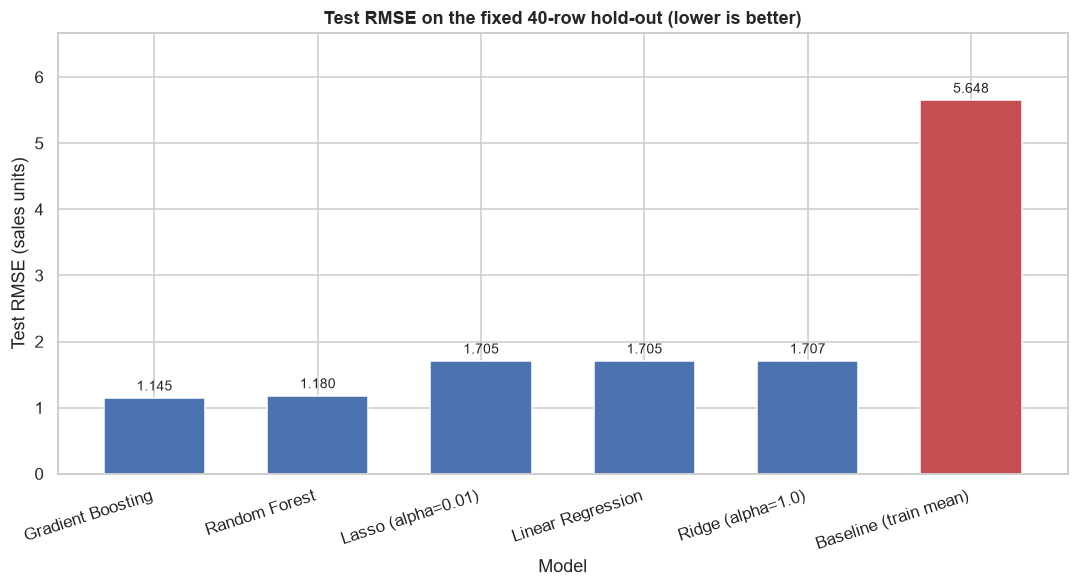

In [18]:
plot_df = comparison.sort_values("Test RMSE")
palette = ["#C44E52" if m.startswith("Baseline") else "#4C72B0" for m in plot_df["Model"]]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(plot_df["Model"], plot_df["Test RMSE"], color=palette, width=0.62)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_title("Test RMSE on the fixed 40-row hold-out (lower is better)")
ax.set_xlabel("Model")
ax.set_ylabel("Test RMSE (sales units)")
ax.set_ylim(0, plot_df["Test RMSE"].max() * 1.18)
ax.tick_params(axis="x", rotation=18)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

fig.tight_layout()
fig.savefig(VIZ_DIR / "06_model_comparison.png")
plt.show()

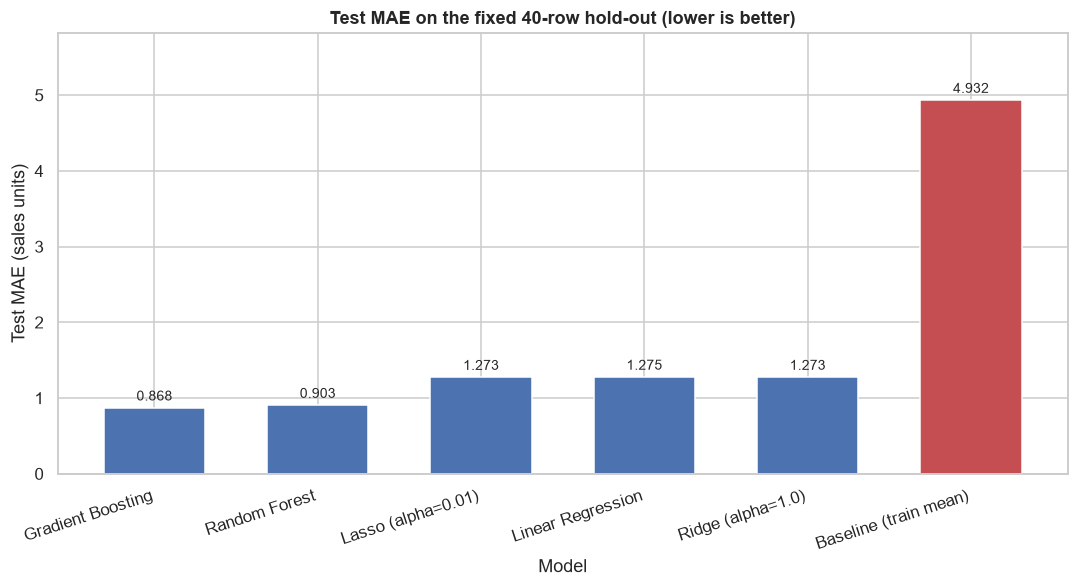

In [19]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.bar(plot_df["Model"], plot_df["Test MAE"], color=palette, width=0.62)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
ax.set_title("Test MAE on the fixed 40-row hold-out (lower is better)")
ax.set_xlabel("Model")
ax.set_ylabel("Test MAE (sales units)")
ax.set_ylim(0, plot_df["Test MAE"].max() * 1.18)
ax.tick_params(axis="x", rotation=18)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

fig.tight_layout()
fig.savefig(VIZ_DIR / "07_model_mae_comparison.png")
plt.show()

Both charts tell the same story, which is itself worth noting: MAE and RMSE agree on the ordering. When they
disagree it usually means one model is making a few unusually large errors; here they do not, so no model is
winning on typical-case accuracy while quietly failing on a handful of observations.

---
## 11. Actual vs Predicted Analysis

The strongest initial candidate by test RMSE is examined in the next four sections. It is selected
mechanically from the comparison table above, not chosen by hand.

In [20]:
candidate_name = comparison.iloc[0]["Model"]
candidate_pipe = {
    "Linear Regression": lin_pipe,
    "Ridge (alpha=1.0)": ridge_pipe,
    "Lasso (alpha=0.01)": lasso_pipe,
    "Random Forest": rf_pipe,
    "Gradient Boosting": gb_pipe,
}[candidate_name]

y_pred = results[candidate_name]["y_test_pred"]
residuals = y_test.to_numpy() - y_pred

print(f"strongest initial candidate by test RMSE: {candidate_name}")
print(f"predictions: {len(y_pred)}  (expected {len(y_test)})")
print(f"any NaN predictions      : {bool(np.isnan(y_pred).any())}")
print(f"any infinite predictions : {bool(np.isinf(y_pred).any())}")

assert len(y_pred) == 40 and np.isfinite(y_pred).all()

strongest initial candidate by test RMSE: Gradient Boosting
predictions: 40  (expected 40)
any NaN predictions      : False
any infinite predictions : False


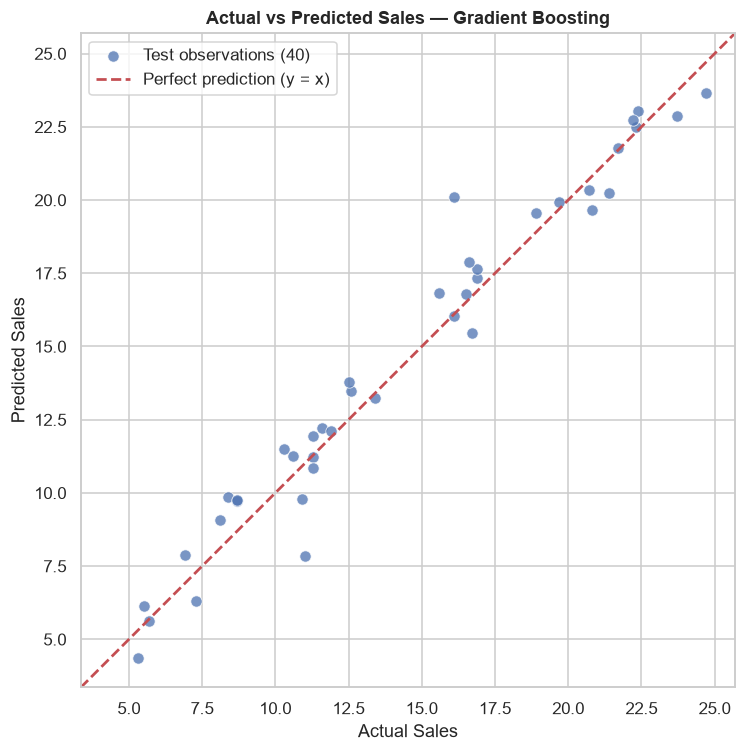

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 7))

lo = min(y_test.min(), y_pred.min()) - 1
hi = max(y_test.max(), y_pred.max()) + 1

ax.scatter(y_test, y_pred, s=55, alpha=0.75, color="#4C72B0", edgecolor="white", linewidth=0.6,
           label="Test observations (40)")
ax.plot([lo, hi], [lo, hi], color="#C44E52", linestyle="--", linewidth=1.8,
        label="Perfect prediction (y = x)")

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.set_title(f"Actual vs Predicted Sales — {candidate_name}")
ax.set_xlabel("Actual Sales")
ax.set_ylabel("Predicted Sales")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(VIZ_DIR / "08_actual_vs_predicted.png")
plt.show()

**Reading the chart.** Each point is one of the 40 test observations. The dashed diagonal is where a perfect
prediction would land — actual equals predicted. **The closer a point sits to that line, the closer the
prediction was**; points above the line are over-predictions and points below it are under-predictions.

The points track the diagonal closely across the whole observed range of the test set, from 5.3 to 24.7
sales units, with two visibly detached from it. There is no obvious curvature or fanning: the model is not systematically
over-predicting low sales and under-predicting high ones, which is the pattern that would show up if it had
missed the overall shape of the relationship.

This describes how closely the model's outputs correspond to observed sales. It says nothing about causation
— the model is fitted to association in observational data, and none of these charts can establish that
changing a budget would move sales.

---
## 12. Residual Analysis

Residual = **actual − predicted**. A positive residual means the model under-predicted.

In [22]:
resid_stats = pd.Series({
    "count": len(residuals),
    "mean": residuals.mean(),
    "median": np.median(residuals),
    "std": residuals.std(ddof=1),
    "min": residuals.min(),
    "max": residuals.max(),
    "skewness": pd.Series(residuals).skew(),
}).to_frame(f"Residuals — {candidate_name}")
resid_stats

,Residuals — Gradient Boosting
count,40.0000
mean,-0.2301
median,-0.3562
std,1.1360
min,-4.0086
max,3.1673
skewness,-0.1029


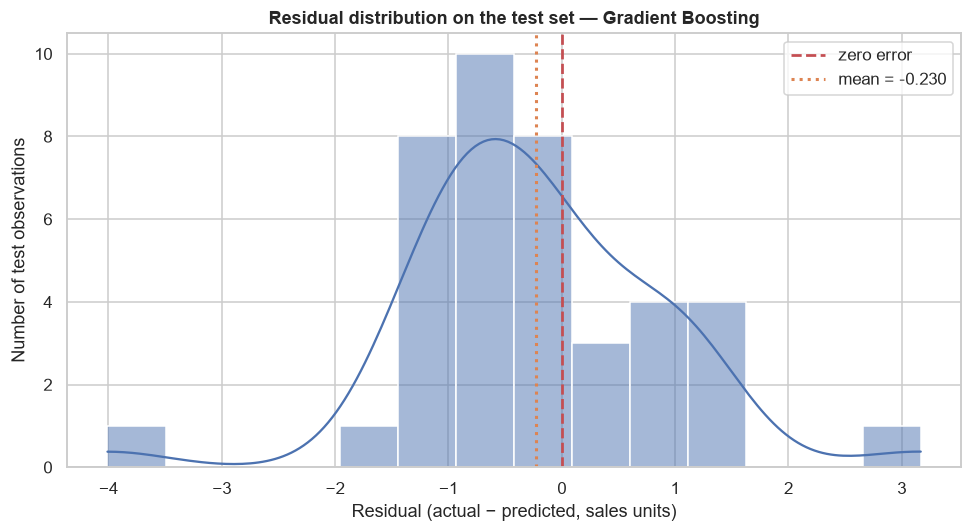

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(residuals, bins=14, kde=True, color="#4C72B0", ax=ax)
ax.axvline(0, color="#C44E52", linestyle="--", linewidth=1.8, label="zero error")
ax.axvline(residuals.mean(), color="#DD8452", linestyle=":", linewidth=2,
           label=f"mean = {residuals.mean():.3f}")
ax.set_title(f"Residual distribution on the test set — {candidate_name}")
ax.set_xlabel("Residual (actual − predicted, sales units)")
ax.set_ylabel("Number of test observations")
ax.legend()

fig.tight_layout()
fig.savefig(VIZ_DIR / "09_residual_distribution.png")
plt.show()

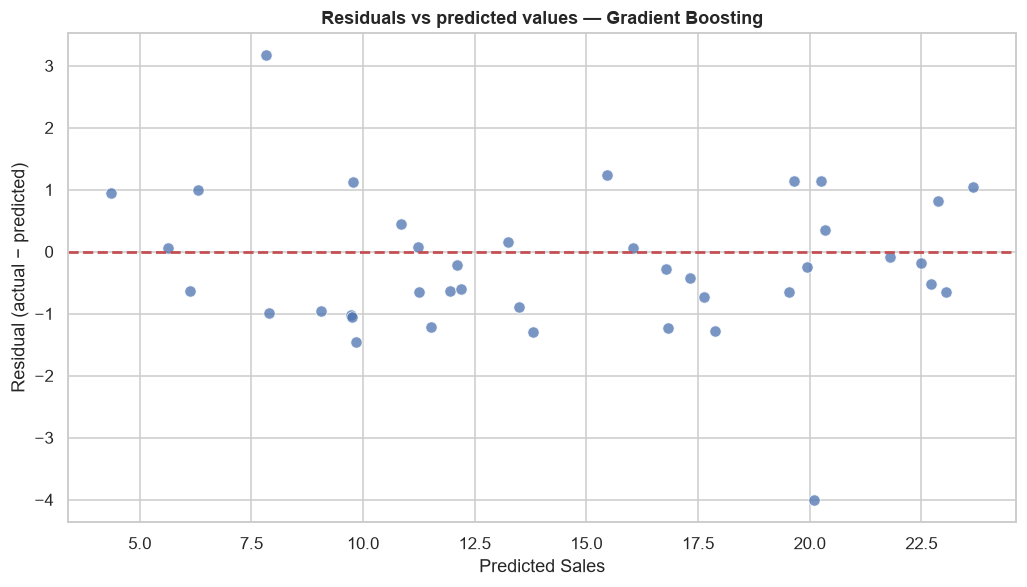

In [24]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.scatter(y_pred, residuals, s=55, alpha=0.75, color="#4C72B0", edgecolor="white", linewidth=0.6)
ax.axhline(0, color="#C44E52", linestyle="--", linewidth=1.8)
ax.set_title(f"Residuals vs predicted values — {candidate_name}")
ax.set_xlabel("Predicted Sales")
ax.set_ylabel("Residual (actual − predicted)")

fig.tight_layout()
fig.savefig(VIZ_DIR / "10_residuals_vs_predicted.png")
plt.show()

**What the residuals show — with 40 observations, read cautiously.**

- **Mean residual −0.2301.** A slight tendency to over-predict on this test set. It is small relative to the
  residual standard deviation (~1.13) and to the scale of `Sales` (1.6–27.0), and on 40 rows a mean this size
  is not distinguishable from zero. Not evidence of systematic bias, but worth re-checking in Phase 4.
- **Distribution roughly centred and single-peaked**, skewness −0.103, with most residuals inside ±1.5 sales
  units and two clearly detached points at about −4.0 and +3.2.
- **Residuals vs predicted shows no obvious funnel.** The spread does not visibly widen as predictions grow.
- **No systematic curvature**, so no strong sign that the model is missing an obvious pattern in the range
  covered.

Forty points cannot support strong claims about the shape of an error distribution, and nothing more is
claimed here. The two large residuals are examined individually in section 13.

---
## 13. Error Analysis

In [25]:
error_table = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred,
    "Residual": residuals,
    "Absolute Error": np.abs(residuals),
}, index=y_test.index).sort_values("Absolute Error", ascending=False)

assert len(error_table) == 40, "Error table must contain one row per test observation."

print(f"error table rows: {len(error_table)}")
error_table.head(10)

error table rows: 40


,Actual Sales,Predicted Sales,Residual,Absolute Error
150,16.1000,20.1086,-4.0086,4.0086
66,11.0000,7.8327,3.1673,3.1673
170,8.4000,9.8499,-1.4499,1.4499
16,12.5000,13.7991,-1.2991,1.2991
152,16.6000,17.8810,-1.2810,1.2810
177,16.7000,15.4642,1.2358,1.2358
9,15.6000,16.8307,-1.2307,1.2307
186,10.3000,11.5163,-1.2163,1.2163
30,21.4000,20.2565,1.1435,1.1435
137,20.8000,19.6589,1.1411,1.1411


In [26]:
abs_err = error_table["Absolute Error"]

summary = pd.Series({
    "largest absolute error": abs_err.max(),
    "median absolute error": abs_err.median(),
    "mean absolute error (MAE)": abs_err.mean(),
    "90th percentile absolute error": abs_err.quantile(0.90),
    "within 1 sales unit (%)": (abs_err <= 1).mean() * 100,
    "within 2 sales units (%)": (abs_err <= 2).mean() * 100,
    "over 3 sales units (count)": int((abs_err > 3).sum()),
}).to_frame(f"Test-set errors — {candidate_name}")
summary

,Test-set errors — Gradient Boosting
largest absolute error,4.0086
median absolute error,0.7799
mean absolute error (MAE),0.8679
90th percentile absolute error,1.2828
within 1 sales unit (%),65.0000
within 2 sales units (%),95.0000
over 3 sales units (count),2.0000


In [27]:
worst = error_table.head(2)
display(X_test.loc[worst.index].join(worst))

,TV,Radio,Newspaper,Actual Sales,Predicted Sales,Residual,Absolute Error
150,280.7000,13.9000,37.0000,16.1000,20.1086,-4.0086,4.0086
66,31.5000,24.6000,2.2000,11.0000,7.8327,3.1673,3.1673


**Findings on the 40 test observations.**

- **Largest absolute error: 4.01 sales units** (row 150 — actual 16.1, predicted 20.11, a substantial
  over-prediction).
- **Second largest: 3.17** (row 66 — actual 11.0, predicted 7.83, an under-prediction).
- **Median absolute error: 0.78** — half of all predictions land within about three-quarters of a sales unit.
- **65.0% of predictions fall within 1 sales unit** of the actual value.
- **95.0% fall within 2 sales units.**
- **2 observations** miss by more than 3 — the two named above.

The two worst cases are both observations whose sales do not follow the usual spend-to-sales pattern, in
opposite directions:

- **Row 150** — `TV` 280.7 (near the top of the range), `Radio` 13.9 (low), `Newspaper` 37.0 (moderate).
  Heavy TV spend, but actual sales of only 16.1. The model predicted 20.11, i.e. roughly what that TV budget
  usually accompanies. This observation under-performed what its spend profile would suggest.
- **Row 66** — `TV` 31.5 (well below the 25th percentile), `Radio` 24.6 (about median), `Newspaper` 2.2 (near
  the minimum). Very little spend overall, yet actual sales of 11.0 against a prediction of 7.83. This one
  over-performed its spend profile.

Neither looks like a model defect so much as a reminder that advertising spend does not determine sales
exactly — something the residual spread in Phase 1's scatter plots already showed. Two observations are far
too few to generalise from, and this is noted as something to watch in Phase 4, not as a diagnosed
weakness.

**These are descriptive statistics of one 40-row sample**, not guarantees. "95% within 2 sales units" is a
property of this hold-out; it is not a claim that 95% of future predictions will land there. A sample that
small carries a wide margin of uncertainty, and Phase 4's cross-validation will give a better-grounded
estimate.

---
## 14. Check the Outliers

Phase 1 flagged two observations as statistical outliers, both unusually high `Newspaper` budgets. Phase 2
retained them. The question here is narrow: on this split, did the model predict them unusually badly?

**They are not removed, and nothing is changed as a result of this check.**

In [28]:
q1, q3 = df["Newspaper"].quantile([0.25, 0.75])
upper_bound = q3 + 1.5 * (q3 - q1)
outlier_idx = df.index[df["Newspaper"] > upper_bound]

print(f"Newspaper IQR upper bound: {upper_bound:.4f}")
print(f"flagged rows: {list(outlier_idx)}")
print(f"  in training set: {[i for i in outlier_idx if i in X_train.index]}")
print(f"  in test set    : {[i for i in outlier_idx if i in X_test.index]}")

Newspaper IQR upper bound: 93.6250
flagged rows: [16, 101]
  in training set: [101]
  in test set    : [16]


In [29]:
outliers_in_test = [i for i in outlier_idx if i in X_test.index]

if outliers_in_test:
    view = X_test.loc[outliers_in_test].join(error_table.loc[outliers_in_test])
    view["Error rank (of 40)"] = [
        int(error_table.index.get_loc(i)) + 1 for i in outliers_in_test
    ]
    display(view)

    for i in outliers_in_test:
        err_i = error_table.loc[i, "Absolute Error"]
        rank = int(error_table.index.get_loc(i)) + 1
        print(f"row {i}: absolute error {err_i:.4f} vs median {abs_err.median():.4f} "
              f"and max {abs_err.max():.4f} — rank {rank} of 40")
else:
    print("No flagged row fell in the test set.")

,TV,Radio,Newspaper,Actual Sales,Predicted Sales,Residual,Absolute Error,Error rank (of 40)
16,67.8000,36.6000,114.0000,12.5000,13.7991,-1.2991,1.2991,4


row 16: absolute error 1.2991 vs median 0.7799 and max 4.0086 — rank 4 of 40


**Finding.** Of the two flagged rows, **row 16 fell in the test set and row 101 in the training set**.

Row 16 (`Newspaper` = 114.0, the largest in the dataset) was predicted at 13.80 against an actual 12.5 — an
absolute error of **1.30**, the 4th largest of the 40. That is above the median error of 0.78 but well short
of the worst (4.01), and it sits inside the 95% of predictions that land within 2 sales units.

So on this split the extreme newspaper budget is associated with a somewhat above-average error, but not an
extreme one, and neither of the two worst errors is a flagged row. This is **one observation in one split**
— it cannot establish whether these rows are influential in general. Phase 2's decision to retain them
stands, and Phase 4 can measure influence properly (e.g. Cook's distance on a linear fit) rather than
inferring it from a single prediction.

---
## 15. Check Linear Model Assumptions

A short diagnostic on **Linear Regression** specifically, since the assumptions belong to it rather than to
the tree ensembles. Phase 1 noted that the `TV` vs `Sales` scatter hinted at non-constant variance; this
checks whether the fitted model's residuals are consistent with that.

Deliberately basic — residual distribution, residual vs predicted, and one summary number. No formal test
suite.

In [30]:
lin_train_pred = lin_pipe.predict(X_train)
lin_train_resid = y_train.to_numpy() - lin_train_pred
lin_test_pred = results["Linear Regression"]["y_test_pred"]
lin_test_resid = y_test.to_numpy() - lin_test_pred

print(f"train residuals: mean {lin_train_resid.mean():7.4f} | std {lin_train_resid.std(ddof=1):.4f} | "
      f"min {lin_train_resid.min():.4f} | max {lin_train_resid.max():.4f}")
print(f"test  residuals: mean {lin_test_resid.mean():7.4f} | std {lin_test_resid.std(ddof=1):.4f} | "
      f"min {lin_test_resid.min():.4f} | max {lin_test_resid.max():.4f}")

spread_corr = np.corrcoef(lin_train_pred, np.abs(lin_train_resid))[0, 1]
print(f"\ncorrelation between predicted value and |residual| (training, 160 rows): {spread_corr:.4f}")

train residuals: mean -0.0000 | std 1.6410 | min -7.1874 | max 3.6213
test  residuals: mean -0.3985 | std 1.6791 | min -5.4785 | max 3.0173

correlation between predicted value and |residual| (training, 160 rows): 0.1033


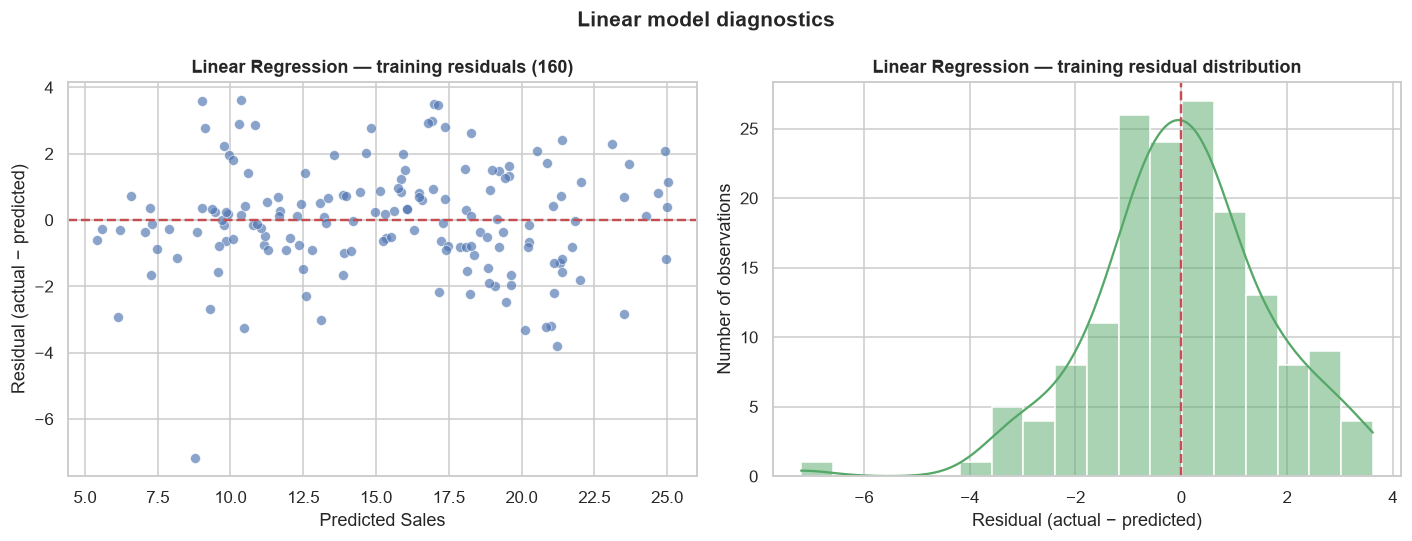

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(lin_train_pred, lin_train_resid, s=42, alpha=0.65, color="#4C72B0",
                edgecolor="white", linewidth=0.5)
axes[0].axhline(0, color="#C44E52", linestyle="--", linewidth=1.6)
axes[0].set_title("Linear Regression — training residuals (160)")
axes[0].set_xlabel("Predicted Sales")
axes[0].set_ylabel("Residual (actual − predicted)")

sns.histplot(lin_train_resid, bins=18, kde=True, color="#55A868", ax=axes[1])
axes[1].axvline(0, color="#C44E52", linestyle="--", linewidth=1.6)
axes[1].set_title("Linear Regression — training residual distribution")
axes[1].set_xlabel("Residual (actual − predicted)")
axes[1].set_ylabel("Number of observations")

fig.suptitle("Linear model diagnostics", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

**Observations, stated cautiously.**

- The training residuals are centred at zero (mean −0.0000, which is definitional for OLS with an
  intercept), but the distribution is clearly **left-skewed**: a long tail of negative residuals reaching
  −7.19, against a maximum of +3.62. The model fits most observations within about ±2 sales units while
  over-predicting badly for a handful.
- The residual-vs-predicted plot shows **no strong systematic curvature**. Residuals scatter on both sides of
  zero across the whole predicted range, so there is no clean "negative at the ends, positive in the middle"
  shape of the sort that would point at an obvious missing quadratic term. What is visible is milder: a
  cluster of negative residuals among the highest predictions (~19–22) and the single large −7.19 miss near a
  prediction of 8.8.
- On **non-constant variance**, the correlation between predicted value and absolute residual is **0.103** on
  the training set — weakly positive, hinting at slightly larger errors at higher predictions, but far too
  weak to confirm the pattern Phase 1 raised. The Phase 1 observation is **neither confirmed nor refuted**
  here; 160 points and a correlation of 0.10 do not settle it either way.
- The linear model's largest test residual is **−5.48**, noticeably worse than the candidate model's −4.01.

Taken together: the linear model's assumptions are not badly violated — residuals are roughly centred, with
no dramatic funnel or curve. But the skewed tail and the ~31% higher test RMSE than either ensemble suggest
it is missing structure that a more flexible model captures. Whether that structure is an interaction term
(such as `TV × Radio`) or something a tree finds is a Phase 4 question, and the evidence here points at it
rather than settling it.

---
## 16. Check for Overfitting

The generalisation gap is **Test RMSE − Train RMSE**. A large gap means a model reproduces its training data
far better than unseen data.

A gap is information, not a verdict. Different model families have structurally different gaps, and a model
with a larger gap can still generalise better in absolute terms — which is exactly what happens here.

In [32]:
gaps = pd.DataFrame([
    {
        "Model": name,
        "Train RMSE": r["train"]["RMSE"],
        "Test RMSE": r["test"]["RMSE"],
        "RMSE gap": r["test"]["RMSE"] - r["train"]["RMSE"],
        "Train R2": r["train"]["R2"],
        "Test R2": r["test"]["R2"],
        "R2 drop": r["train"]["R2"] - r["test"]["R2"],
    }
    for name, r in results.items()
]).sort_values("Test RMSE").reset_index(drop=True)

gaps

,Model,Train RMSE,Test RMSE,RMSE gap,Train R2,Test R2,R2 drop
0,Gradient Boosting,0.4438,1.1451,0.7013,0.9926,0.9576,0.0351
1,Random Forest,0.4716,1.1798,0.7082,0.9917,0.9550,0.0367
2,Lasso (alpha=0.01),1.6360,1.7050,0.0691,0.9001,0.9059,-0.0058
3,Linear Regression,1.6359,1.7052,0.0693,0.9001,0.9059,-0.0058
4,Ridge (alpha=1.0),1.6362,1.7074,0.0713,0.9001,0.9057,-0.0055
5,Baseline (train mean),5.1768,5.6482,0.4714,0.0000,-0.0324,0.0324


**Reading the gaps.**

| Model | Train RMSE | Test RMSE | Gap | Train R² | Test R² |
|---|---|---|---|---|---|
| Gradient Boosting | 0.4438 | 1.1451 | **0.701** | 0.9926 | 0.9576 |
| Random Forest | 0.4716 | 1.1798 | **0.708** | 0.9917 | 0.9550 |
| Lasso (α=0.01) | 1.6360 | 1.7050 | **0.069** | 0.9001 | 0.9059 |
| Linear Regression | 1.6359 | 1.7052 | **0.069** | 0.9001 | 0.9059 |
| Ridge (α=1.0) | 1.6362 | 1.7074 | **0.071** | 0.9001 | 0.9057 |
| Baseline | 5.1768 | 5.6482 | 0.471 | 0.0000 | −0.0324 |

Two distinct patterns:

- **The linear models generalise almost perfectly flatly** — gaps of ~0.07, and test R² marginally *higher*
  than train R². A 3-parameter model on 160 rows has very little capacity to memorise, so this is expected.
  It also means their ~1.705 RMSE is close to the best a straight-line fit can do here; the limitation is the
  model's form, not a shortage of data.
- **Both tree ensembles show gaps of ~0.70** with train R² above 0.99. They fit the training rows very
  closely — unsurprising for an unrestricted forest, and for 200 boosting stages on 160 rows.

**The gap alone does not disqualify them.** Despite fitting training data far more closely, both ensembles
predict *unseen* data about 31% better than any linear model. Test RMSE is what matters for generalisation,
and on that measure they win clearly.

What the gap does indicate is **headroom**: the ensembles are using more capacity than the problem may need.
Constraining them (shallower trees, a minimum leaf size, fewer or more slowly-learned stages) might close the
gap and improve test performance. That is a Phase 4 experiment, to be run with cross-validation on the
training set — not by trying settings against this hold-out.

One caveat on all of the above: the gaps are computed against a 40-row test set, so each is itself an
uncertain estimate.

---
## 17. Reproducibility

Every result above must be reproducible, or the comparison means nothing. Checked in two ways.

In [33]:
refit = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso (alpha=0.01)": Lasso(alpha=0.01, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
}

repro_rows = []
for name, estimator in refit.items():
    pipe = make_pipeline(estimator)
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    original = results[name]["y_test_pred"]
    repro_rows.append({
        "Model": name,
        "Bit-identical": bool(np.array_equal(preds, original)),
        "Max abs difference": float(np.abs(preds - original).max()),
        "Equal within float tolerance": bool(np.allclose(preds, original)),
        "Test RMSE (4 dp) identical": bool(
            round(float(np.sqrt(mean_squared_error(y_test, preds))), 4)
            == round(results[name]["test"]["RMSE"], 4)),
    })

repro = pd.DataFrame(repro_rows)
display(repro.style.format({"Max abs difference": "{:.3e}"}))

assert repro["Equal within float tolerance"].all(), "A model did not reproduce its predictions."
assert repro["Test RMSE (4 dp) identical"].all(), "A model's reported metric did not reproduce."

exact = repro.loc[repro["Bit-identical"], "Model"].tolist()
inexact = repro.loc[~repro["Bit-identical"], "Model"].tolist()
print("bit-identical on refit :", exact)
print("differs at float noise :", inexact if inexact else "none")

,Model,Bit-identical,Max abs difference,Equal within float tolerance,Test RMSE (4 dp) identical
0,Linear Regression,True,0.000e+00,True,True
1,Ridge (alpha=1.0),True,0.000e+00,True,True
2,Lasso (alpha=0.01),True,0.000e+00,True,True
3,Random Forest,False,1.066e-14,True,True
4,Gradient Boosting,True,0.000e+00,True,True


bit-identical on refit : ['Linear Regression', 'Ridge (alpha=1.0)', 'Lasso (alpha=0.01)', 'Gradient Boosting']
differs at float noise : ['Random Forest']


In [34]:
split_again = dp.make_train_test_split(X, y, test_size=dp.TEST_SIZE, random_state=dp.RANDOM_STATE)
print("split reproducible:",
      split_again.X_train.equals(X_train) and split_again.X_test.equals(X_test)
      and split_again.y_train.equals(y_train) and split_again.y_test.equals(y_test))
print("baseline value reproducible:", np.isclose(float(split_again.y_train.mean()), baseline_value))

split reproducible: True
baseline value reproducible: True


### One source of non-determinism, identified

Four of the five models refit **bit-identically**. `Random Forest` does not: its predictions differ by up to
about **1 x 10^-14** — a handful of machine-epsilon units at this magnitude, and the exact figure varies
from run to run, which is itself the signature of the cause.

This is documented rather than smoothed over, because the cause matters. It is **not** that the forest is
trained differently on each run - `random_state=42` fixes every bootstrap sample and every split, so the 300
trees are identical. It is that `n_jobs=-1` averages those trees' outputs across worker threads, and
floating-point addition is not associative: summing the same 300 numbers in a different order can change the
last bit of the result.

The check below confirms the diagnosis - with `n_jobs=1`, which forces a single deterministic summation
order, the forest is bit-identical too.

In [35]:
serial_a = make_pipeline(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1))
serial_b = make_pipeline(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1))
serial_a.fit(X_train, y_train)
serial_b.fit(X_train, y_train)

pred_a, pred_b = serial_a.predict(X_test), serial_b.predict(X_test)
print("Random Forest with n_jobs=1, refitted twice - bit-identical:", np.array_equal(pred_a, pred_b))
print("agrees with the n_jobs=-1 result within float tolerance   :",
      np.allclose(pred_a, results["Random Forest"]["y_test_pred"]))
print(f"max difference vs the n_jobs=-1 result                    : "
      f"{np.abs(pred_a - results['Random Forest']['y_test_pred']).max():.3e}")

Random Forest with n_jobs=1, refitted twice - bit-identical: True
agrees with the n_jobs=-1 result within float tolerance   : True
max difference vs the n_jobs=-1 result                    : 1.066e-14


**Result.** The split, the baseline value and every reported metric reproduce exactly. Four models refit
bit-identically; the Random Forest agrees to around 1e-14, which is roughly twelve orders of magnitude below
the 4-decimal precision everything is reported at and cannot affect a single conclusion in this notebook.
With `n_jobs=1` it is bit-identical too, confirming that parallel summation order is the whole explanation.

`RandomForestRegressor` and `GradientBoostingRegressor` are stochastic algorithms - they bootstrap and
subsample - but `random_state=42` fixes those draws, so the fitted models themselves are deterministic.
`LinearRegression`, `Ridge` and `Lasso` are deterministic given the data; `random_state` is passed to Ridge
and Lasso only for explicitness and has no effect with their default solvers.

**No unexplained stochastic behaviour remains.** The one deviation is understood, bounded and reported.

---
## 18. Initial Model Selection

In [36]:
top_two = comparison.head(2)
rmse_diff = float(top_two.iloc[1]["Test RMSE"] - top_two.iloc[0]["Test RMSE"])
mae_diff = float(top_two.iloc[1]["Test MAE"] - top_two.iloc[0]["Test MAE"])

print(f"Initial candidate for Phase 4: {candidate_name}")
print()
print(f"  test RMSE {results[candidate_name]['test']['RMSE']:.4f}"
      f"  |  test MAE {results[candidate_name]['test']['MAE']:.4f}"
      f"  |  test R2 {results[candidate_name]['test']['R2']:.4f}")
print(f"  improvement over baseline: "
      f"{(baseline_rmse - results[candidate_name]['test']['RMSE']) / baseline_rmse * 100:.1f}% RMSE, "
      f"{(baseline_mae - results[candidate_name]['test']['MAE']) / baseline_mae * 100:.1f}% MAE")
print()
print(f"  runner-up: {top_two.iloc[1]['Model']}")
print(f"  RMSE difference: {rmse_diff:.4f}  |  MAE difference: {mae_diff:.4f}")
print(f"  as a share of the candidate's RMSE: {rmse_diff / top_two.iloc[0]['Test RMSE'] * 100:.1f}%")

Initial candidate for Phase 4: Gradient Boosting

  test RMSE 1.1451  |  test MAE 0.8679  |  test R2 0.9576
  improvement over baseline: 79.7% RMSE, 82.4% MAE

  runner-up: Random Forest
  RMSE difference: 0.0347  |  MAE difference: 0.0346
  as a share of the candidate's RMSE: 3.0%


### Initial candidate for Phase 4: **Gradient Boosting Regressor**

Selected on the evidence available in this phase:

- **Lowest test RMSE** on the fixed hold-out (1.1451) and **lowest test MAE** (0.8679).
- **Highest test R²** (0.9576).
- Residuals centred near zero with no obvious funnel or curvature, and the smallest worst-case error of the
  models examined.
- 79.7% lower RMSE than the naive baseline.

### Two things this conclusion is not

**It is not a final selection.** Every configuration here was fixed in advance and scored once on 40 rows.
Phase 4 will compare models properly, with cross-validation on the training set, and only then will a final
model be chosen and evaluated once on the hold-out.

**Gradient Boosting and Random Forest are not meaningfully separated.** They differ by 0.0347 RMSE units —
about 3% of the candidate's own RMSE — on a 40-row sample. That is comfortably inside the noise, and a
different random split could easily reverse the order. Both should be carried into Phase 4 as live
candidates; the label "initial candidate" reflects a tie-break on this hold-out, not a demonstrated
advantage.

The linear models are a different matter: their ~1.705 RMSE is clearly worse than either ensemble (~31%), and
their residual structure suggests why. They remain worth keeping in Phase 4 as interpretable reference
points, and an interaction term is worth testing, but on current evidence they are not the leading approach.

---
## 19. Phase 3 Conclusions

In [37]:
checksum = dp.verify_raw_dataset_integrity()
dataset_path = dp.default_dataset_path()

print("file    :", dataset_path.relative_to(PROJECT_DIR))
print("size    :", dataset_path.stat().st_size, "bytes")
print("sha-256 :", checksum)
print("expected:", dp.RAW_DATASET_SHA256)
print("matches Phase 1:", checksum == dp.RAW_DATASET_SHA256)

models_dir = PROJECT_DIR / "models"
persisted = [p.name for p in models_dir.iterdir() if p.name != ".gitkeep"]
print("\nartefacts in models/:", persisted if persisted else "none — nothing persisted in Phase 3")
assert not persisted, "Phase 3 must not persist a model artefact."

file    : dataset\advertising.csv
size    : 4062 bytes
sha-256 : 137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5
expected: 137f755ad6fd3bc6471085f7631a2fba6c04cb8acd71eaf5cc9af6839d43fdd5
matches Phase 1: True

artefacts in models/: none — nothing persisted in Phase 3


### What Phase 3 established

| | |
|---|---|
| **Split** | the Phase 2 hold-out reused unchanged — 160 train / 40 test, `random_state=42` |
| **Baseline** | predicting the training mean (15.3306) → test RMSE 5.6482, MAE 4.9315, R² −0.0324 |
| **Models fitted** | Linear Regression, Ridge (α=1.0), Lasso (α=0.01), Random Forest (300 trees), Gradient Boosting (200 stages) |
| **All beat the baseline** | by roughly 70–80% on test RMSE |
| **Linear cluster** | 1.7050–1.7074 test RMSE — the three are indistinguishable |
| **Ensemble cluster** | 1.1451–1.1798 test RMSE — about 31% better than the linear models |
| **Initial candidate** | Gradient Boosting (test RMSE 1.1451), with Random Forest statistically level |
| **Error profile** | median absolute error 0.78; 65% of predictions within 1 sales unit, 95% within 2; worst miss 4.01 |
| **Generalisation gaps** | ~0.07 for linear models, ~0.70 for both ensembles |
| **Outliers** | retained; the one in the test set had the 4th largest error of 40 — above median, not extreme |
| **Raw data** | checksum unchanged |
| **Persisted artefacts** | none |
| **Reproducibility** | split, baseline and all metrics reproduce exactly; 4/5 models bit-identical, Random Forest agrees to ~7e-15 because of parallel summation order (section 17) |

### Carried into Phase 4

- Use cross-validation **on the training set** for all model comparison and tuning. The 40-row hold-out has
  now been used for its one permitted purpose and should not drive any further decision.
- Treat Gradient Boosting and Random Forest as **joint** leading candidates, not as first and second.
- Investigate the ensembles' ~0.70 generalisation gap by constraining capacity (tree depth, minimum leaf
  size, learning rate, number of stages) — there may be test-set improvement available.
- Test an **interaction term** (e.g. `TV × Radio`) for the linear models. The ensembles' advantage and the
  curvature in the linear residuals both point at non-additive structure.
- Re-examine the slight negative mean residual (−0.23) on a larger validation sample to see whether it
  reflects real bias or sampling noise.
- Measure the influence of the two retained `Newspaper` observations directly, rather than inferring it from
  a single prediction.

**No hyperparameter was tuned, no search was run, no model was saved, and the test set was scored once per
model.** Phase 4 handles improvement and final selection.